In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
from fft_sup_imports import * 
%matplotlib inline
update_rc_params('paper')

R: 131.681, Bf: 0.888 $\(10^{12}$ cm$^{-2})$, gamma: 43.528 deg, $lpha T_D$: 25.766 T
tau_q: 0.347 ps
R: 66.402, Bf: 1.186 $\(10^{12}$ cm$^{-2})$, gamma: -48.410 deg, $lpha T_D$: 23.164 T
tau_q: 0.386 ps
R: 1.544, Bf: 0.908 $\(10^{12}$ cm$^{-2})$, gamma: -26.810 deg, $lpha T_D$: 2.454 T
tau_q: 3.639 ps


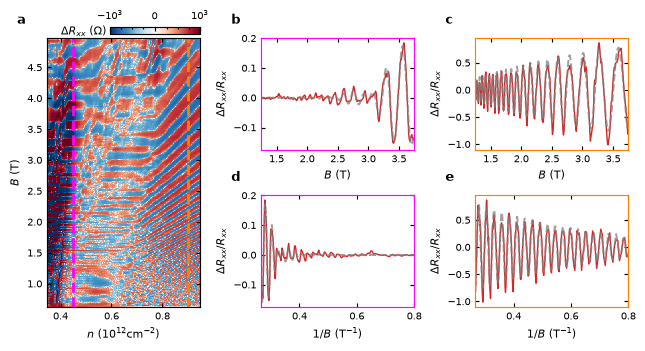

In [2]:
fig = plt.figure(figsize=(7.5, 3.5))
gs = GridSpec(2, 3, hspace=0.4, wspace=0.4, 
    # height_ratios=[4,4,1]
)

ax_lf = plt.subplot(gs[:,0])
axes_B = [plt.subplot(gs[0, i+1]) for i in range(2)]
axes_invB = [plt.subplot(gs[1, i+1]) for i in range(2)]
# axes_fitinfo = [plt.subplot(gs[2,i+1]) for i in range(2)]

letters = list(map(chr, range(97, 97+26)))


analyzer = Lf_analysis(1840, contact=2)
label_spacer = 0.04
norm_lf = colors.SymLogNorm(linthresh=1, vmin=-1e3, vmax=1E3)

# Map
ax = ax_lf
pos = ax.get_position()
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, 'a', fontweight='bold')
plot = analyzer.plot_lf(fig, ax, norm_lf,
    bg_method=detrend_butterworth,                         
    bg_method_params={'cutoff': None, 'order': 4}, # Cutoff = None --> 4 periods
    blims=(0.62, 4.98),
    cmap='RdBu_r'
)
cb_width = 0.12
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])
cb = plt.colorbar(plot, cax=cax, ticks=SymmetricalLogLocator(base=10, linthresh=500), \
                 orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
cb.ax.set_xlabel(r'$\Delta R_{xx}$ ($\Omega$)', labelpad=-18, x=-0.29)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top#
cb.ax.xaxis.set_label_position('top') 
cb.set_ticks([-1000, 0, 1000])
cb.set_ticklabels(['$-10^3$', '$0$', '$10^3$'])

# Plot linecuts
ax.vlines(density_targets, 0.62, 4.98, colors=density_colors, linestyle='dashed', alpha=1, lw=2)
ax.set_ylim(0.62, 4.98)

### Compute linecuts and fits ### 
# First, plot them on (a)


B, Rxx, bg = analyzer.get_bg_subtracted_data(detrend_butterworth, {'cutoff': 8*0.228, 'order': 4}, (0.62, 4.98), return_bg=True)



# def fit_func_two_tone(B, R1, Bf1, gamma1, R2, Bf2, gamma2, tau_q):
#     # mstar = m_star_emass*m_e
#     mstar = 0.5 *m_e
#     beta = 2 * np.pi**2 * k_B *mstar/ (hbar*e*B)
#     tau_q = tau_q * 1e-12
#     T_D = hbar/(2*np.pi * k_B * tau_q)
#     T = 32.28490895348038 * 1e-3 # K, T_probe
#     Rt = beta*T/np.sinh(beta*T)
#     RD = np.exp(-beta*T_D)
#     return Rt * RD * (R1*np.cos(2 * np.pi* (Bf1/B + gamma1)) + R2*np.cos(2 * np.pi* (Bf2/B+gamma2)))



def fit_func_one_tone(B, R, Bf, gamma, tau_q):
    # mstar = m_star_emass*m_e
    mstar = 0.5 *m_e
    beta = 2 * np.pi**2 * k_B *mstar/ (hbar*e*B)
    tau_q = tau_q * 1e-12
    T_D = hbar/(2*np.pi * k_B * tau_q)
    T = 32.28490895348038 * 1e-3 # K, T_probe
    Rt = beta*T/np.sinh(beta*T)
    RD = np.exp(-beta*T_D) 
    return  RD * R* np.cos(2 * np.pi* (Bf/B + gamma)) 
    # return Rt * RD * R* np.cos(2 * np.pi* (Bf/B + gamma)) 

def fit_func_two_tone(B, R1, Bf1, gamma1, tau_q1, R2, Bf2, gamma2, tau_q2):
    return fit_func_one_tone(B, R1, Bf1, gamma1, tau_q1) + fit_func_one_tone(B, R2, Bf2, gamma2, tau_q2)


p0_QM = [
    1, 0.9*1*phi0*1e16, 0, # second tone amp, freq, phase
    10, # Tau_q(ps)
]
p0_two_tone = [
    0.2, 0.93*phi0*1e16, 0, 1,  # first tone amp, freq, phase, Tau_q(ps)
    0.1, 1.16*phi0*1e16, 0, 1,  # second tone amp, freq, phase, Tau_q(ps)
]
lobounds = [0, 0, -np.pi, 0]
hibounds = [np.inf, np.inf, np.pi, 100]
fit_funcs = [fit_func_two_tone, fit_func_one_tone]
p0s = [p0_two_tone, p0_QM]


def tau_to_alpha_TD(tau_q):
    T_D = hbar/(2*np.pi * k_B * tau_q)
    m_star_emass = 0.5
    alpha = 2 * np.pi**2 * k_B *m_star_emass*m_e/ (hbar*e)
    return alpha*T_D # In Tesla

def popt_printer(popt):
    popt_s = np.reshape(popt, (-1, 4))
    for row in popt_s:
        R, Bf, gamma, tau_q = row
        nunitstr = r'$\(10^{12}$ cm$^{-2})$'
        print(f"R: {R:.3f}, Bf: {Bf*1e-16/phi0:.3f} {nunitstr}, gamma: {np.rad2deg(gamma):.3f} deg, $\alpha T_D$: {tau_to_alpha_TD(tau_q*1e-12):.3f} T")
        print(f"tau_q: {tau_q:.3f} ps")
fit_blims = (1.0, 3.75)

# Plots in B
for i, (ax_B, ax_invB) in enumerate(zip(axes_B, axes_invB)):
    n_idx = np.argmin(np.abs(analyzer.density-density_targets[i]))
    n = analyzer.density[n_idx]
    norm_rxx = Rxx[:,n_idx]/np.median(np.abs(bg[:,n_idx]))
    fit_bmask = (fit_blims[0]<B) & (B<fit_blims[1])
    norm_rxx = norm_rxx[fit_bmask]
    Bfit = B[fit_bmask]
    # 


    # B
    ax = ax_B
    pos = ax.get_position()
    fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, letters[i+1], fontweight='bold')
    ax.plot(Bfit, norm_rxx, lw=1, color='tab:red')
    ax.set_xlabel('$B$ (T)')

    #### Do the fit #### 
    popt, pcov = scipy.optimize.curve_fit(
        fit_funcs[i], Bfit, norm_rxx,
        p0 = p0s[i],
        bounds = [
            np.tile(lobounds, 2) if i==0 else lobounds,
            np.tile(hibounds, 2) if i==0 else hibounds
        ]
    )
    # Plot results
    ax.plot(Bfit, fit_funcs[i](Bfit, *popt), ls="--", color="gray", alpha=0.75)
    ax.set_xlim(1.25, 3.75)
    ax.set_ylabel(r'$\Delta R_{xx}/ R_{xx} $')

    # invB
    ax = ax_invB
    pos = ax.get_position()
    fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, letters[i+3], fontweight='bold')
    ax.plot(1/Bfit, norm_rxx, lw=1, color='tab:red')
    ax.plot(1/Bfit, fit_funcs[i](Bfit, *popt), ls="--", color="gray", alpha=0.75)
    ax.set_xlabel(r'$1/B$ $\left(\mathrm{T}^{-1}\right)$')
    ax.set_xlim(1/3.75, 1/1.25)
    ax.set_ylabel(r'$\Delta R_{xx}/R_{xx}$')
    for ax in (ax_B, ax_invB):
        for spine in ax.spines.values():
            spine.set_edgecolor(density_colors[i])    
    popt_printer(popt)

plt.savefig('figS_FFT_linecutsandfits.pdf', dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)


In [3]:
tau_q = 0.347 * 1e-12
def tau_to_alpha_TD(tau_q):
    T_D = hbar/(2*np.pi * k_B * tau_q)
    m_star_emass = 0.5
    alpha = 2 * np.pi**2 * k_B *m_star_emass*m_e/ (hbar*e)
    return alpha*T_D # In Tesla
tau_to_alpha_TD(tau_q)

25.73765675605953

$$
    \alpha T_{\mathrm{D}} = \frac{2 \pi^2 k_B}{\hbar e} m^{\ast} \frac{\hbar}{2 \pi k_B \tau_q} = \frac{\pi}{e} \frac{m^{\ast}}{\tau_q}
$$